<a href="https://colab.research.google.com/github/shake345/Python100knock/blob/main/6%E7%AB%A0_%E5%8A%A0%E5%B7%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 下記セルを実行すると、authorization codeの入力を求められます。
# 出力されたリンク先をクリックし、Googleアカウントにログインし、
# authorization codeをコピーし、貼り付けをおこなってください。
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
project = '100knock-process-visualization'
chapter = 6
os.chdir(f'/content/drive/MyDrive/{project}/chapter-{chapter}/')

# ６章 音声データの加工・可視化１０本ノック



## ノック７１：音データを再生してみよう

In [4]:
import IPython.display as disp
disp.Audio('data/音声.mp3')

In [5]:
disp.Audio('data/携帯電話着信音.mp3')

## ノック７２：音データを読み込んでみよう

In [6]:
import librosa
audio1,sr1 = librosa.load('data/音声.mp3',sr=None)
print(audio1)
print(sr1)

[ 0.          0.          0.         ... -0.00418601 -0.00416326
 -0.00401785]
44100


In [7]:
print(audio1.shape)
print(audio1.max())
print(audio1.min())

(46080,)
0.71468115
-0.5591311


In [8]:
audio2,sr2 = librosa.load('data/携帯電話着信音.mp3',sr=None)
print(audio2)
print(sr2)
print(audio2.shape)

[ 0.          0.          0.         ... -0.00509245 -0.00407731
 -0.00323255]
44100
(101376,)


## ノック７３：音データの一部を取得してみよう

In [9]:
audio2,sr2 = librosa.load('data/携帯電話着信音.mp3',sr=None,offset=0,duration=1)
print(audio2)
print(sr2)
print(audio2.shape)

[0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 8.8994158e-05 7.2300778e-04
 1.7945722e-03]
44100
(44100,)


In [10]:
disp.Audio(data=audio2,rate=sr2)

In [11]:
audio1,sr1 = librosa.load('data/音声.mp3',sr=None,offset=0,duration=1)
disp.Audio(data=audio1,rate=sr1)
print(audio1.shape)

(44100,)


## ノック７４：音データのサンプリングレートを変えてみよう

In [12]:
audio1_sr22,sr1_sr22 = librosa.load('data/音声.mp3',sr=22050,offset=0,duration=1)
print(audio1_sr22)
print(sr1_sr22)
print(audio1_sr22.shape)

[-1.4432899e-15 -3.1641356e-15  8.6597396e-15 ...  2.2931159e-03
  1.9602906e-03  2.4683489e-03]
22050
(22050,)


In [14]:
audio1_sr8 = librosa.resample(audio1, orig_sr=sr1, target_sr=8000)
print(audio1_sr8)
print(audio1_sr8.shape)

[-6.2504793e-11 -4.6593673e-11 -1.3691157e-10 ...  2.2176565e-03
  2.0332159e-03  2.3386339e-03]
(8000,)


In [15]:
librosa.get_samplerate('data/音声.mp3')

44100

## ノック７５：音データを可視化してみよう

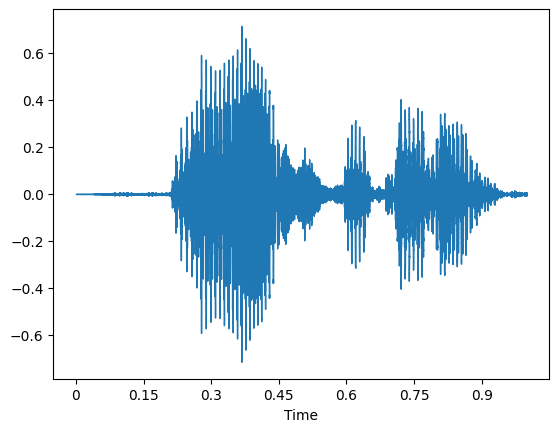

In [17]:
import librosa.display as libdisp
libdisp.waveshow(audio1,sr=sr1)

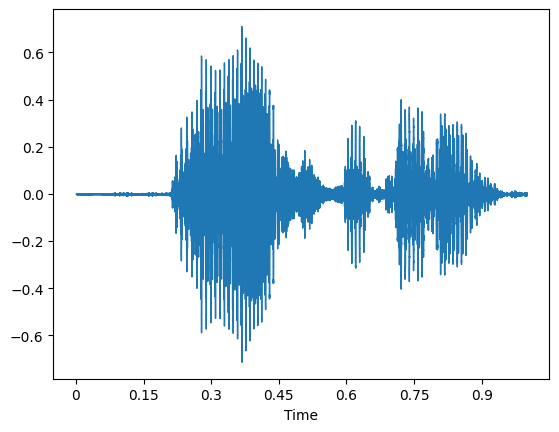

In [18]:
libdisp.waveshow(audio1_sr22,sr=sr1_sr22)

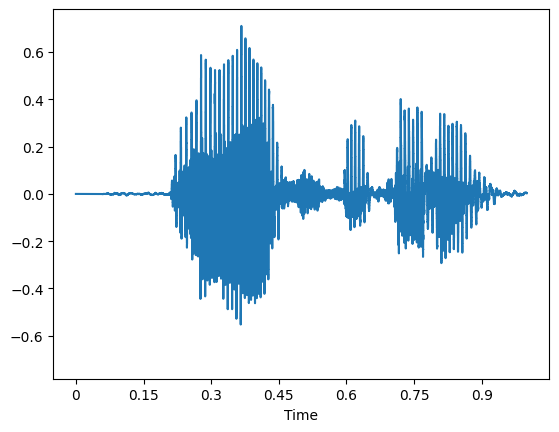

In [19]:
libdisp.waveshow(audio1_sr8,sr=8000)

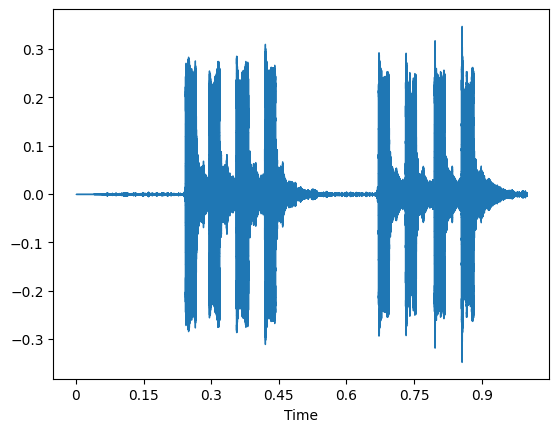

In [20]:
libdisp.waveshow(audio2,sr=sr2)

## ノック７６：音データの大きさを取得してみよう

In [21]:
import numpy as np
audio1_rms = np.sqrt(np.mean(audio1**2))
audio2_rms = np.sqrt(np.mean(audio2**2))
print(audio1_rms)
print(audio2_rms)

0.117136106
0.07960443


In [22]:
rms1 = librosa.feature.rms(y=audio1)
time1 = librosa.times_like(rms1,sr=sr1)
print(rms1.shape)
rms1

(1, 87)


array([[0.00000000e+00, 0.00000000e+00, 3.26023041e-06, 6.15759127e-05,
        3.26528039e-04, 9.28180583e-04, 1.43364549e-03, 2.11794162e-03,
        2.83022108e-03, 2.95363134e-03, 2.78255367e-03, 2.47683562e-03,
        2.14898819e-03, 2.37140572e-03, 2.54095322e-03, 2.70694494e-03,
        2.72329897e-03, 1.75013021e-02, 4.15570773e-02, 6.69912845e-02,
        8.92795622e-02, 1.18809819e-01, 1.51561230e-01, 1.74796283e-01,
        1.94208369e-01, 2.03803346e-01, 2.03455791e-01, 2.08877102e-01,
        2.23944947e-01, 2.33912215e-01, 2.52728432e-01, 2.57646561e-01,
        2.62712061e-01, 2.63533294e-01, 2.47948259e-01, 2.44444311e-01,
        2.12403521e-01, 1.78452983e-01, 1.47364497e-01, 9.61780176e-02,
        6.73961416e-02, 5.44461161e-02, 5.00178114e-02, 4.58628945e-02,
        4.36514057e-02, 4.05725278e-02, 3.09379026e-02, 2.19069142e-02,
        1.59058906e-02, 1.20766889e-02, 4.20555100e-02, 6.77456483e-02,
        8.71006921e-02, 1.05747320e-01, 1.02373555e-01, 8.810358

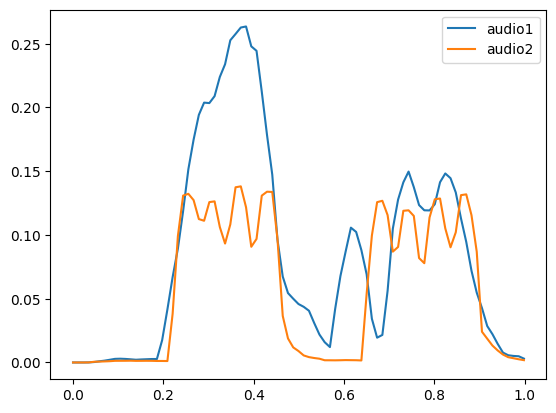

In [23]:
import matplotlib.pyplot as plt
rms2 = librosa.feature.rms(y=audio2)
time2 = librosa.times_like(rms2,sr=sr2)
plt.plot(time1,rms1[0],label='audio1')
plt.plot(time2,rms2[0],label='audio2')
plt.legend()

## ノック７７：周波数スペクトルを表示してみよう

## ノック７８：スペクトログラムを可視化してみよう

## ノック７９：音の高さや長さを変えてみよう

## ノック８０：音データを保存しよう